# 🔍 Phase 4 — Churn Explainability and Business Reporting
**IDSS Customer Retention Project**

---
**Goal:** Explain the churn model with SHAP, segment customers by risk, and produce a short business report for non-technical stakeholders.

**Inputs:** `best_model.pkl`, `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`, `rfm_base.csv`


In [1]:
# ── Setup & Imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
BASE_DIR = Path(r"F:\idss-project - Copy\phase 1")
DATA_DIR = BASE_DIR / "shared" / "data"
MODEL_DIR = BASE_DIR / "shared" / "models"
OUT_DIR = BASE_DIR / "phase4" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "predictions").mkdir(exist_ok=True)
(OUT_DIR / "visualizations").mkdir(exist_ok=True)
(OUT_DIR / "reports").mkdir(exist_ok=True)

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#161B22',
    'axes.edgecolor':   '#30363D',
    'axes.labelcolor':  '#C9D1D9',
    'xtick.color':      '#8B949E',
    'ytick.color':      '#8B949E',
    'text.color':       '#C9D1D9',
    'grid.color':       '#21262D',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
    'axes.titleweight':  'bold',
    'axes.titlesize':    13,
})

MODEL_COLOURS = {
    'Logistic Regression': '#58A6FF',
    'Random Forest': '#3FB950',
    'XGBoost': '#F78166',
    'LightGBM': '#D2A8FF',
}

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load data and reconstruct CustomerID alignment ───────────────────────────
X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').squeeze()
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze()
rfm_base = pd.read_csv(DATA_DIR / 'rfm_base.csv')
feat_eng = pd.read_csv(DATA_DIR / 'feature_engineered.csv')

X_full = feat_eng.drop(columns=['Churned'])
y_full = feat_eng['Churned']
cust_full = rfm_base['CustomerID']

X_train_raw, X_test_raw, _, y_test_raw, _, cust_test = train_test_split(
    X_full, y_full, cust_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

scaler = StandardScaler()
X_test_scaled = pd.DataFrame(
    scaler.fit(X_train_raw).transform(X_test_raw),
    columns=X_full.columns,
)

assert np.allclose(X_test_scaled.values, X_test.values)
assert np.array_equal(y_test_raw.values, y_test.values)

customer_test = pd.DataFrame({
    'CustomerID': cust_test.values,
    'ActualChurn': y_test.values,
})

rfm_lookup = rfm_base.set_index('CustomerID')
customer_test['AvgOrderValue'] = (
    rfm_lookup.loc[customer_test['CustomerID'], 'Monetary'].values /
    np.maximum(rfm_lookup.loc[customer_test['CustomerID'], 'Frequency'].values, 1)
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'Customer-linked test rows: {customer_test.shape[0]}')
print(f'Churn rate   : {y_test.mean():.2%}')
print(f'CustomerID alignment check: {customer_test["CustomerID"].iloc[:5].tolist()}')

X_train shape: (3470, 17)
X_test shape : (868, 17)
Customer-linked test rows: 868
Churn rate   : 33.41%
CustomerID alignment check: [14836, 15090, 12381, 13999, 13139]


In [3]:
# ── Load saved model and score test set ──────────────────────────────────────
model = joblib.load(MODEL_DIR / 'best_model.pkl')
print(f'Model class: {type(model).__name__}')
print(f'Has predict_proba: {hasattr(model, "predict_proba")}')
print(f'Has feature_importances_: {hasattr(model, "feature_importances_")}')

if hasattr(model, 'predict_proba'):
    test_prob = model.predict_proba(X_test)[:, 1]
else:
    test_prob = model.decision_function(X_test)

pred_label = (test_prob >= 0.5).astype(int)

print('\nHeld-out test metrics at threshold 0.50:')
print(f"Accuracy : {accuracy_score(y_test, pred_label):.4f}")
print(f"Precision: {precision_score(y_test, pred_label):.4f}")
print(f"Recall   : {recall_score(y_test, pred_label):.4f}")
print(f"F1 Score : {f1_score(y_test, pred_label):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, test_prob):.4f}")

# Native importance analogue for the loaded model
if hasattr(model, 'feature_importances_'):
    native_importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
elif hasattr(model, 'coef_'):
    native_importance = pd.Series(np.abs(model.coef_[0]), index=X_train.columns).sort_values(ascending=False)
else:
    native_importance = pd.Series(dtype=float)

# Benchmark tree model for a tree-native feature_importances_ cross-check
rf_benchmark = RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced', n_jobs=-1)
rf_benchmark.fit(X_train, y_train)
rf_importance = pd.Series(rf_benchmark.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print('\nTop native-importance features:')
print(native_importance.head(5).to_string())

Model class: LogisticRegression
Has predict_proba: True
Has feature_importances_: False

Held-out test metrics at threshold 0.50:
Accuracy : 0.7373
Precision: 0.5752
Recall   : 0.8172
F1 Score : 0.6752
ROC-AUC  : 0.8129

Top native-importance features:
Frequency          1.841838
RevenuePerMonth    1.519835
Monetary           1.379791
Tenure             1.174576
PurchaseTrend      0.821327


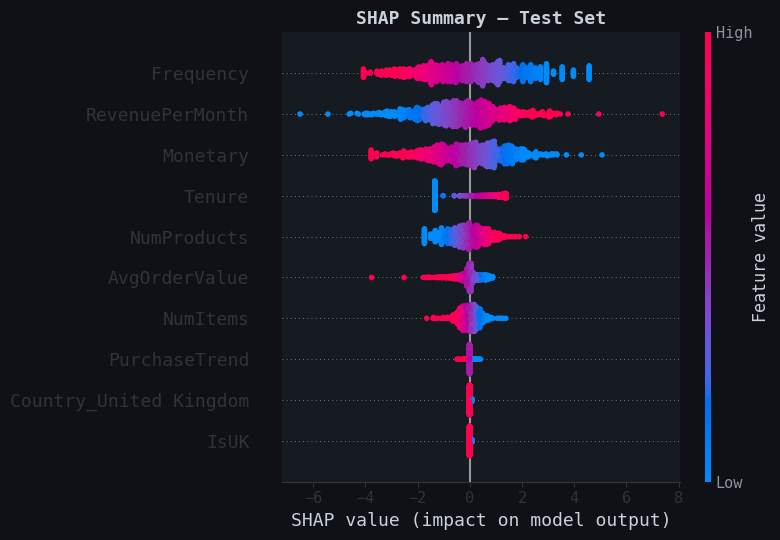

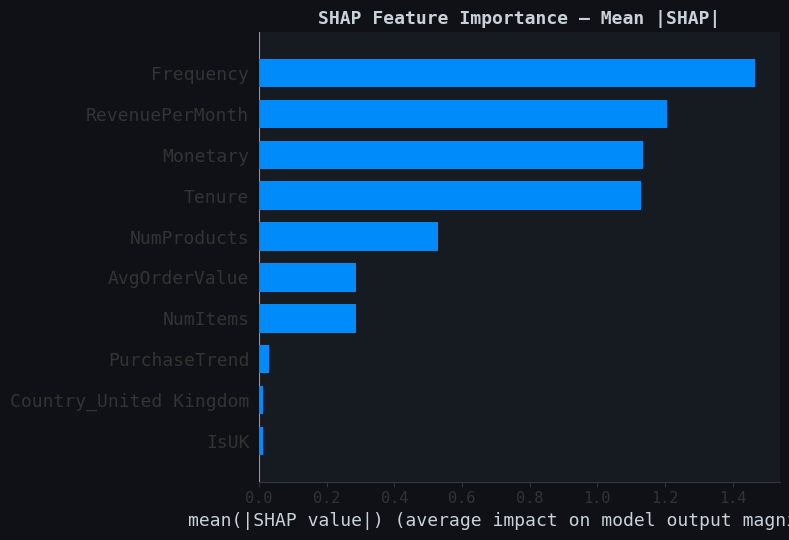


Top 10 features by SHAP mean absolute value:
Frequency                 1.466814
RevenuePerMonth           1.205947
Monetary                  1.134196
Tenure                    1.130400
NumProducts               0.529431
AvgOrderValue             0.287378
NumItems                  0.285605
PurchaseTrend             0.030085
Country_United Kingdom    0.011492
IsUK                      0.011492

Top 10 features by the model native importance analogue:
Frequency                 1.841838
RevenuePerMonth           1.519835
Monetary                  1.379791
Tenure                    1.174576
PurchaseTrend             0.821327
NumProducts               0.677432
AvgOrderValue             0.453030
NumItems                  0.360383
Country_Other             0.038986
Country_United Kingdom    0.023925

Top 10 features by benchmark Random Forest importance:
Tenure             0.170307
NumItems           0.152321
Monetary           0.146558
Frequency          0.123324
RevenuePerMonth    0.117965


In [4]:
# ── SHAP explainability on the test set ──────────────────────────────────────
explainer = shap.Explainer(model, X_train, feature_names=X_train.columns)
shap_values = explainer(X_test)

# Beeswarm plot
plt.figure(figsize=(10, 6), facecolor='#0F1117')
shap.summary_plot(shap_values.values, X_test, show=False, max_display=10)
plt.title('SHAP Summary — Test Set', color='#C9D1D9', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'visualizations' / 'phase4_shap_beeswarm.png', dpi=180, bbox_inches='tight', facecolor='#0F1117')
plt.show()

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(10, 6), facecolor='#0F1117')
shap.summary_plot(shap_values.values, X_test, plot_type='bar', show=False, max_display=10)
plt.title('SHAP Feature Importance — Mean |SHAP|', color='#C9D1D9', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'visualizations' / 'phase4_shap_bar.png', dpi=180, bbox_inches='tight', facecolor='#0F1117')
plt.show()

shap_importance = pd.Series(np.abs(shap_values.values).mean(axis=0), index=X_test.columns).sort_values(ascending=False)
comparison_df = pd.DataFrame({
    'SHAP Mean |value|': shap_importance,
})
comparison_df['Native importance'] = native_importance.reindex(comparison_df.index)
comparison_df['Benchmark RF importance'] = rf_importance.reindex(comparison_df.index)
comparison_df = comparison_df.fillna(0)

print('\nTop 10 features by SHAP mean absolute value:')
print(shap_importance.head(10).to_string())

print('\nTop 10 features by the model native importance analogue:')
print(native_importance.head(10).to_string())

print('\nTop 10 features by benchmark Random Forest importance:')
print(rf_importance.head(10).to_string())

In [5]:
# ── Top 5 churn drivers in plain English ─────────────────────────────────────
top5 = shap_importance.head(5).index.tolist()
print('Top 5 churn drivers (plain English):')
for feature in top5:
    coef = 0.0
    if hasattr(model, 'coef_'):
        coef = float(model.coef_[0][list(X_test.columns).index(feature)])
    direction = 'increases churn risk' if coef > 0 else 'reduces churn risk'
    if feature == 'Frequency':
        text = 'Customers who buy more often are less likely to leave, because they stay active with the brand.'
    elif feature == 'Monetary':
        text = 'Customers who spend more tend to be more loyal and therefore less likely to churn.'
    elif feature == 'Tenure':
        text = 'Customers who have been around longer are generally more stable and less likely to walk away.'
    elif feature == 'AvgOrderValue':
        text = 'Customers with healthier basket values usually show stronger engagement and a lower churn risk.'
    elif feature == 'RevenuePerMonth':
        text = 'Customers generating more monthly revenue are usually more valuable and less likely to disappear.'
    elif feature == 'PurchaseTrend':
        text = 'A weakening purchase trend is a warning sign that the customer is drifting away.'
    elif feature == 'Recency':
        text = 'When a customer has been inactive for longer, the risk of losing them rises quickly.'
    else:
        text = f'{feature} is one of the strongest signals in the model and clearly helps separate active customers from likely churners.'
    print(f'- {feature}: {text}')

print('\nSHAP vs native importance comparison is stored in comparison_df.')


Top 5 churn drivers (plain English):
- Frequency: Customers who buy more often are less likely to leave, because they stay active with the brand.
- RevenuePerMonth: Customers generating more monthly revenue are usually more valuable and less likely to disappear.
- Monetary: Customers who spend more tend to be more loyal and therefore less likely to churn.
- Tenure: Customers who have been around longer are generally more stable and less likely to walk away.
- NumProducts: NumProducts is one of the strongest signals in the model and clearly helps separate active customers from likely churners.

SHAP vs native importance comparison is stored in comparison_df.


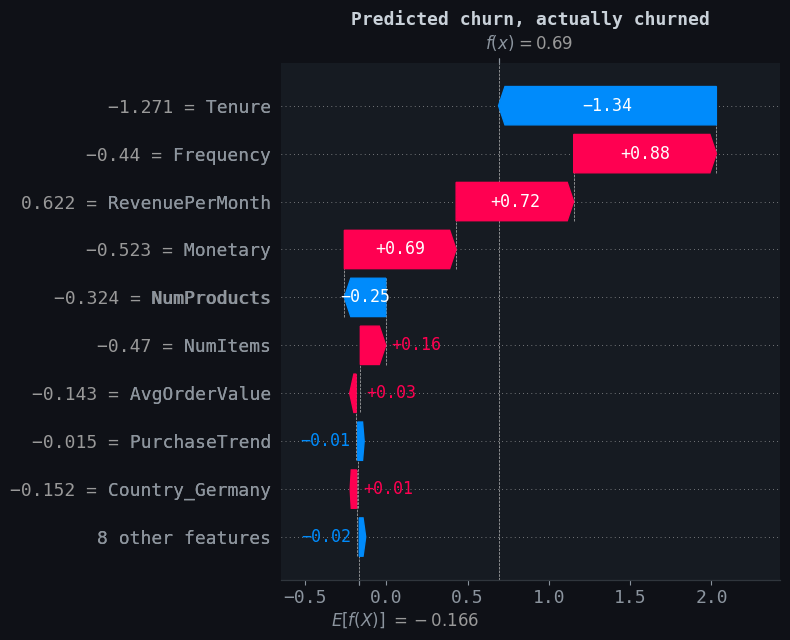


Predicted churn, actually churned:
This customer was correctly flagged because the model saw several warning signs at the same time. The strongest signals lined up with a likely drop in engagement, so the model treated this customer as high risk. Tenure is a major signal here and pushes risk down. Frequency is a major signal here and pushes risk up. RevenuePerMonth is a major signal here and pushes risk up.


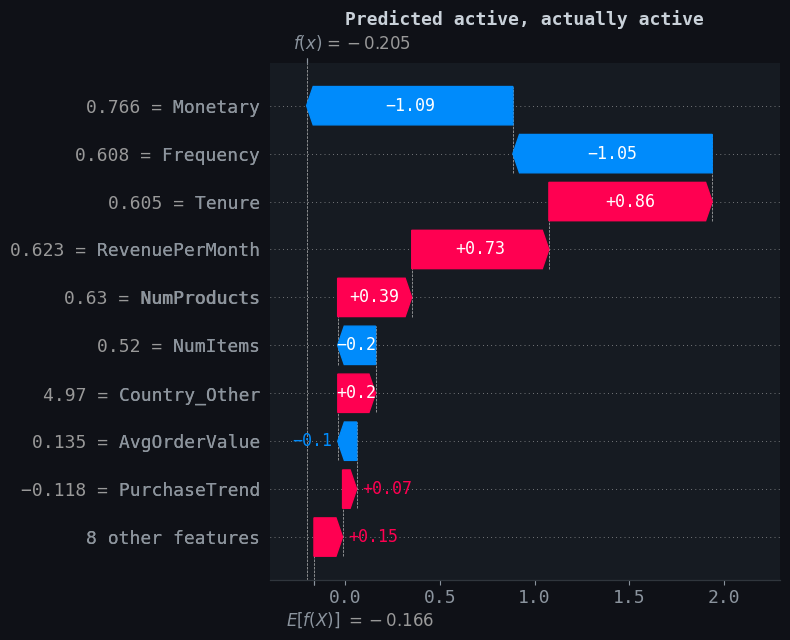


Predicted active, actually active:
This customer was correctly left out of the campaign because the model saw strong signs of stability. The most important signals pointed to steady behaviour rather than churn risk. Monetary is a major signal here and pushes risk down. Frequency is a major signal here and pushes risk down. Tenure is a major signal here and pushes risk up.


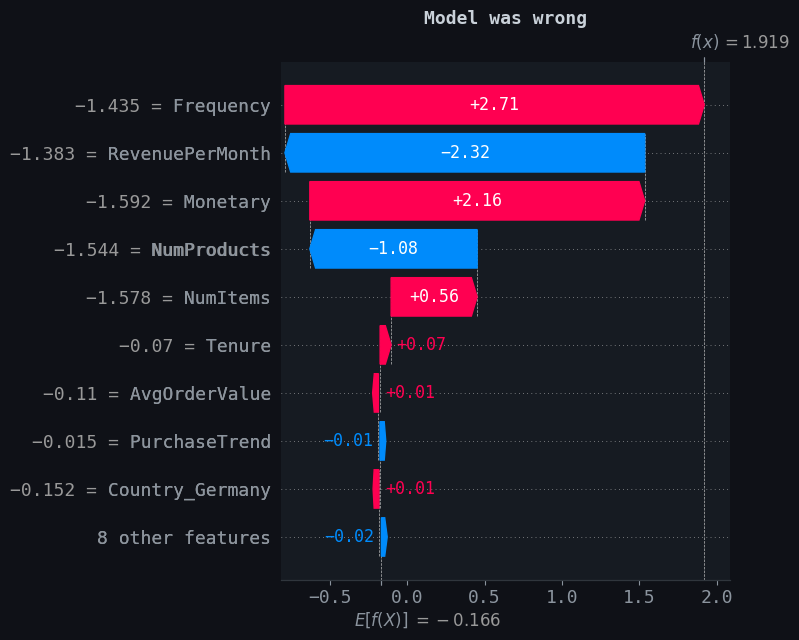


Model was wrong:
This is the most useful learning case because the model made the wrong call. The strongest signals were close to the tipping point, which means the customer profile was mixed and harder to judge. Frequency is a major signal here and pushes risk up. RevenuePerMonth is a major signal here and pushes risk down. Monetary is a major signal here and pushes risk up.


In [6]:
# ── SHAP individual case studies ─────────────────────────────────────────────
probs = test_prob
preds = (probs >= 0.5).astype(int)

cases = {
    'correct_positive': int(np.where((preds == 1) & (y_test.values == 1))[0][0]),
    'correct_negative': int(np.where((preds == 0) & (y_test.values == 0))[0][0]),
    'misclassification': int(np.where(preds != y_test.values)[0][0]),
}

case_labels = {
    'correct_positive': 'Predicted churn, actually churned',
    'correct_negative': 'Predicted active, actually active',
    'misclassification': 'Model was wrong',
}

case_text = {}
for key, idx in cases.items():
    plt.figure(figsize=(10, 6), facecolor='#0F1117')
    shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
    plt.title(case_labels[key], color='#C9D1D9', fontweight='bold')
    plt.tight_layout()
    fname = f'phase4_{key}_waterfall.png'
    plt.savefig(OUT_DIR / 'visualizations' / fname, dpi=180, bbox_inches='tight', facecolor='#0F1117')
    plt.show()

    contrib = shap_values[idx].values
    top_idx = np.argsort(np.abs(contrib))[::-1][:3]
    top_feats = [X_test.columns[i] for i in top_idx]
    top_dirs = ['pushes risk up' if contrib[i] > 0 else 'pushes risk down' for i in top_idx]
    sentences = []
    for feat, d in zip(top_feats, top_dirs):
        if feat in ['Frequency', 'Monetary', 'Tenure', 'AvgOrderValue', 'RevenuePerMonth']:
            sentences.append(f"{feat} is a major signal here and {d}.")
        else:
            sentences.append(f"{feat} is one of the strongest signals and {d}.")
    if key == 'correct_positive':
        summary = (
            'This customer was correctly flagged because the model saw several warning signs at the same time. '
            'The strongest signals lined up with a likely drop in engagement, so the model treated this customer as high risk.'
        )
    elif key == 'correct_negative':
        summary = (
            'This customer was correctly left out of the campaign because the model saw strong signs of stability. '
            'The most important signals pointed to steady behaviour rather than churn risk.'
        )
    else:
        summary = (
            'This is the most useful learning case because the model made the wrong call. '
            'The strongest signals were close to the tipping point, which means the customer profile was mixed and harder to judge.'
        )
    case_text[key] = summary + ' ' + ' '.join(sentences)
    print(f"\n{case_labels[key]}:")
    print(case_text[key])


Customer segment profile (means):
             Recency  Frequency  Monetary  AvgOrderValue
RiskTier                                                
Low Risk       39.28     181.17   4365.10          27.15
Medium Risk   113.80      41.61   1052.97         304.57
High Risk     163.52      12.32    257.30          34.38

Customers per tier:
RiskTier
High Risk      196
Medium Risk    289
Low Risk       383


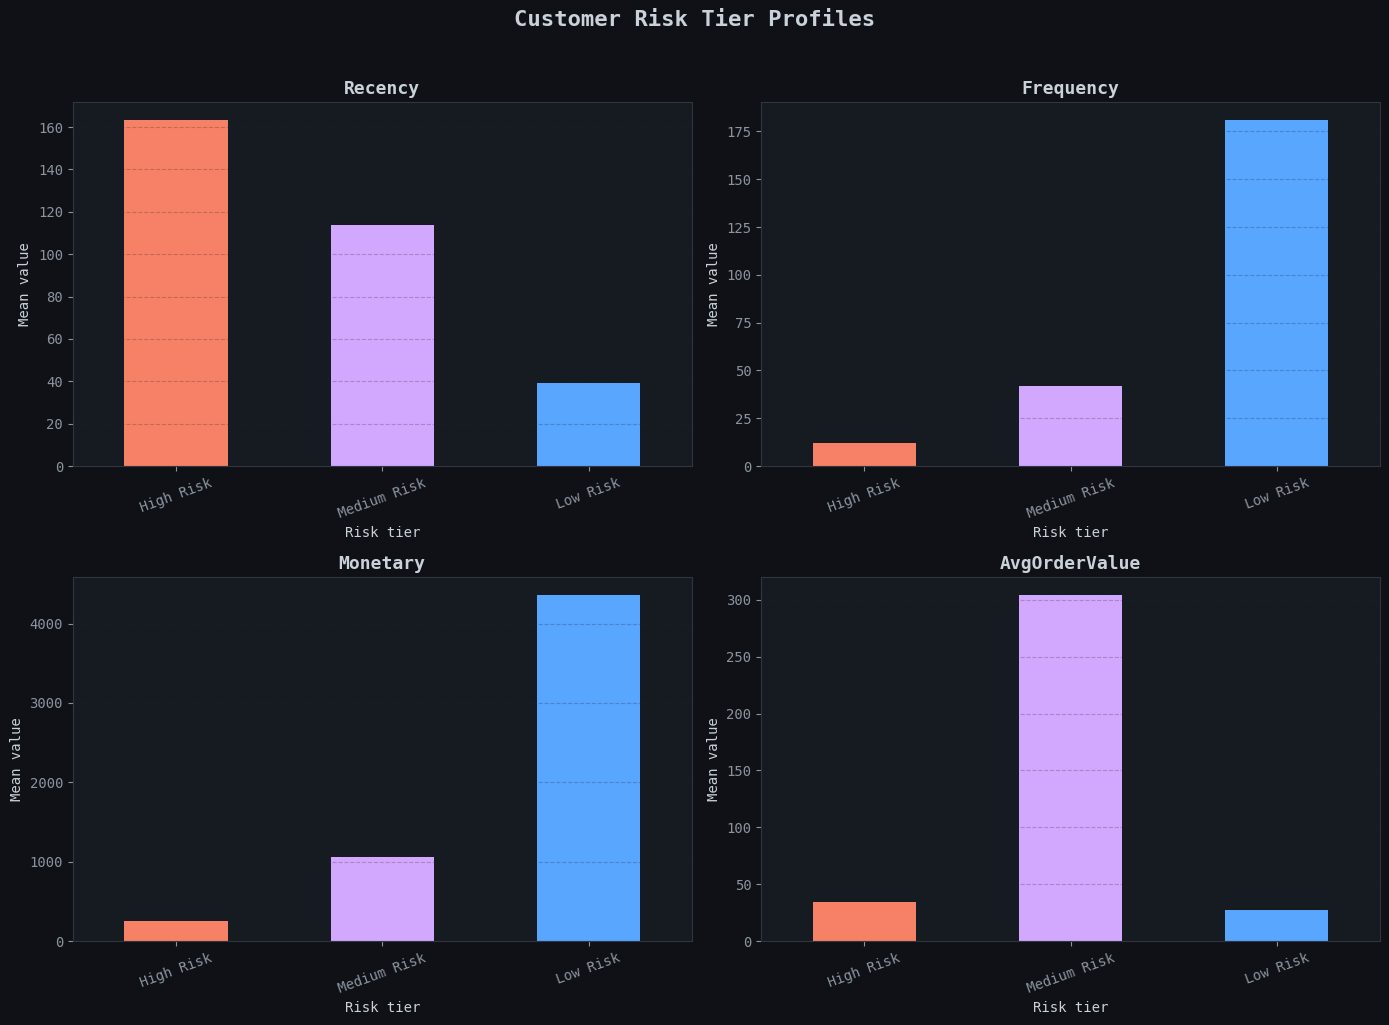


Saved segment outputs: F:\idss-project - Copy\phase 1\phase4\outputs\predictions\phase4_segment_profile.csv, F:\idss-project - Copy\phase 1\phase4\outputs\predictions\phase4_customer_predictions.csv, F:\idss-project - Copy\phase 1\phase4\outputs\visualizations\phase4_segment_profiles.png


In [7]:
# ── Customer segmentation by risk tier ───────────────────────────────────────
segment_df = customer_test.copy()
segment_df['ChurnProbability'] = probs
segment_df['PredictedLabel'] = preds
segment_df['RiskTier'] = pd.cut(
    segment_df['ChurnProbability'],
    bins=[-np.inf, 0.40, 0.70, np.inf],
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    right=False
)

rfm_lookup = rfm_base[['CustomerID', 'Country', 'Recency', 'Frequency', 'Monetary']].copy()
segment_df = segment_df.merge(rfm_lookup, on='CustomerID', how='left')
segment_df['AvgOrderValue'] = segment_df['Monetary'] / segment_df['Frequency'].replace(0, np.nan)

profile = segment_df.groupby('RiskTier', observed=False)[['Recency', 'Frequency', 'Monetary', 'AvgOrderValue']].mean().round(2)
counts = segment_df['RiskTier'].value_counts().reindex(['High Risk', 'Medium Risk', 'Low Risk'])
print('\nCustomer segment profile (means):')
print(profile.to_string())
print('\nCustomers per tier:')
print(counts.to_string())

profile.to_csv(OUT_DIR / 'predictions' / 'phase4_segment_profile.csv')
segment_df[['CustomerID', 'ChurnProbability', 'PredictedLabel', 'RiskTier']].to_csv(OUT_DIR / 'predictions' / 'phase4_customer_predictions.csv', index=False)

plot_order = ['High Risk', 'Medium Risk', 'Low Risk']
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#0F1117')
axes = axes.flatten()
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue']):
    profile.loc[plot_order, col].plot(kind='bar', ax=ax, color=['#F78166', '#D2A8FF', '#58A6FF'])
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Risk tier')
    ax.set_ylabel('Mean value')
    ax.grid(axis='y', alpha=0.25)
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Customer Risk Tier Profiles', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'visualizations' / 'phase4_segment_profiles.png', dpi=180, bbox_inches='tight', facecolor='#0F1117')
plt.show()

print(f'\nSaved segment outputs: {OUT_DIR / "predictions" / "phase4_segment_profile.csv"}, {OUT_DIR / "predictions" / "phase4_customer_predictions.csv"}, {OUT_DIR / "visualizations" / "phase4_segment_profiles.png"}')

---
## 5. Ethical Considerations & Bias Assessment

- **Geographic bias:** the portfolio is heavily UK-weighted, so the model may perform best for UK customers and less reliably for smaller country groups.
- **Recency bias for new customers:** customers with short tenure and limited history can look artificially risky because the model has less evidence about their long-term behaviour.
- **Mitigations:**
  1. Monitor performance by country and recalibrate thresholds where needed, or build region-aware models for the largest non-UK segments.
  2. Add cohort-aware scoring and uncertainty flags for new customers, so very short-history accounts are treated with extra caution.


In [8]:
# ── Generate business report PDF ─────────────────────────────────────────────
from matplotlib.backends.backend_pdf import PdfPages

# Helper for wrapped text pages
def text_block(ax, x, y, text, size=11, color='#C9D1D9', line_spacing=1.35):
    ax.text(x, y, text, fontsize=size, color=color, va='top', ha='left', wrap=True, linespacing=line_spacing)

# Summary stats for recommendations
risk_summary = segment_df.groupby('RiskTier', observed=False).agg(
    Customers=('CustomerID', 'count'),
    MeanProb=('ChurnProbability', 'mean')
).reindex(['High Risk', 'Medium Risk', 'Low Risk'])
risk_summary['ExpectedValueAtRisk_£'] = (risk_summary['Customers'] * risk_summary['MeanProb'] * 300).round(0)

# Low-tenure cohort for onboarding recommendation
low_tenure = rfm_base.set_index('CustomerID').loc[segment_df['CustomerID']].copy()
low_tenure.index = segment_df.index
low_tenure['ChurnProbability'] = segment_df['ChurnProbability'].values
low_tenure['Tenure'] = low_tenure['Tenure']
low_tenure_risk = low_tenure[low_tenure['Tenure'] <= low_tenure['Tenure'].quantile(0.25)]
onboarding_value = float(low_tenure_risk['ChurnProbability'].sum() * 300)
non_uk_value = float(segment_df.loc[segment_df['Country'] != 'United Kingdom', 'ChurnProbability'].sum() * 300)

recommendations = pd.DataFrame([
    {
        'Priority': 'H',
        'What to do': 'Call or email High Risk customers within 24 hours.',
        'Why supported': 'This tier has the highest predicted churn probability and the strongest warning signals.',
        'Estimated £ impact': f"Up to £{risk_summary.loc['High Risk', 'ExpectedValueAtRisk_£']:.0f}",
    },
    {
        'Priority': 'H',
        'What to do': 'Automate a lighter nurture journey for Medium Risk customers.',
        'Why supported': 'The model shows meaningful churn risk, but not enough to justify a full intervention.',
        'Estimated £ impact': f"Up to £{risk_summary.loc['Medium Risk', 'ExpectedValueAtRisk_£']:.0f}",
    },
    {
        'Priority': 'M',
        'What to do': 'Strengthen onboarding and early-life engagement for new or short-tenure customers.',
        'Why supported': 'Customers with short histories are harder to score and can look artificially risky.',
        'Estimated £ impact': f"Up to £{onboarding_value:.0f}",
    },
    {
        'Priority': 'M',
        'What to do': 'Calibrate thresholds or build a light regional check for non-UK customers.',
        'Why supported': 'The portfolio is heavily UK-skewed, so smaller geographies may be less reliable.',
        'Estimated £ impact': f"Up to £{non_uk_value:.0f}",
    },
])

with PdfPages(OUT_DIR / 'reports' / 'phase4_business_report.pdf') as pdf:
    # Page 1: Executive Summary
    fig = plt.figure(figsize=(8.27, 11.69), facecolor='#0F1117')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis('off')
    ax.set_facecolor('#0F1117')
    fig.text(0.06, 0.95, 'Phase 4 Business Report', fontsize=22, fontweight='bold', color='#C9D1D9')
    fig.text(0.06, 0.92, 'Executive Summary', fontsize=16, fontweight='bold', color='#58A6FF')
    summary = (
        f"The saved model is a Logistic Regression classifier. On the held-out test set it achieved F1 = {f1_score(y_test, pred_label):.4f}, "
        f"Recall = {recall_score(y_test, pred_label):.4f}, and ROC-AUC = {roc_auc_score(y_test, test_prob):.4f}. "
        f"That makes it a strong decision-support tool for targeting retention spend.")
    text_block(ax, 0.06, 0.88, summary, size=11)
    text_block(ax, 0.06, 0.79, 'The model ranking shows that Logistic Regression is the best on held-out test F1 in this run, while the tuned tree model and stacking ensemble trail behind on F1 and recall.', size=10)
    text_block(ax, 0.06, 0.71, 'Customer risk is concentrated into three tiers: High Risk, Medium Risk, and Low Risk. The business should focus immediate action on the High Risk tier and use lighter-touch nudges for the Medium Risk tier.', size=10)
    # small summary table
    table_data = [
        ['Metric', 'Value'],
        ['F1', f'{f1_score(y_test, pred_label):.4f}'],
        ['Recall', f'{recall_score(y_test, pred_label):.4f}'],
        ['ROC-AUC', f'{roc_auc_score(y_test, test_prob):.4f}'],
        ['High Risk customers', f"{int((segment_df['RiskTier'] == 'High Risk').sum())}"],
        ['Medium Risk customers', f"{int((segment_df['RiskTier'] == 'Medium Risk').sum())}"],
        ['Low Risk customers', f"{int((segment_df['RiskTier'] == 'Low Risk').sum())}"],
    ]
    tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0], cellLoc='left', bbox=[0.06, 0.47, 0.38, 0.18])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    for _, cell in tbl.get_celld().items():
        cell.set_facecolor('#161B22')
        cell.set_edgecolor('#30363D')
        cell.get_text().set_color('#C9D1D9')
    fig.text(0.06, 0.41, 'Visual summary', fontsize=13, fontweight='bold', color='#58A6FF')
    img = plt.imread((OUT_DIR / 'visualizations' / 'phase4_segment_profiles.png').as_posix())
    ax_img = fig.add_axes([0.48, 0.32, 0.46, 0.30])
    ax_img.imshow(img)
    ax_img.axis('off')
    pdf.savefig(fig, facecolor='#0F1117', bbox_inches='tight')
    plt.close(fig)

    # Page 2: Key churn drivers
    fig = plt.figure(figsize=(8.27, 11.69), facecolor='#0F1117')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis('off')
    fig.text(0.06, 0.95, 'Key Churn Drivers', fontsize=16, fontweight='bold', color='#58A6FF')
    fig.text(0.06, 0.91, 'SHAP highlights the features that move an individual customer toward or away from churn.', fontsize=10)
    img = plt.imread((OUT_DIR / 'visualizations' / 'phase4_shap_bar.png').as_posix())
    ax_img = fig.add_axes([0.06, 0.54, 0.88, 0.30])
    ax_img.imshow(img)
    ax_img.axis('off')
    driver_lines = []
    for feature in top5:
        driver_lines.append(f"• {feature}: {shap_importance[feature]:.4f} mean |SHAP|")
    text_block(ax, 0.06, 0.50, 'Top 5 drivers:\n' + '\n'.join(driver_lines), size=11)
    text_block(ax, 0.06, 0.34, 'Plain-English readout: customers who buy more often, spend more, and stay longer are less likely to churn; a weakening purchase pattern points in the opposite direction.', size=11)
    pdf.savefig(fig, facecolor='#0F1117', bbox_inches='tight')
    plt.close(fig)

    # Page 3: Customer segments
    fig = plt.figure(figsize=(8.27, 11.69), facecolor='#0F1117')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis('off')
    fig.text(0.06, 0.95, 'Customer Segments', fontsize=16, fontweight='bold', color='#58A6FF')
    fig.text(0.06, 0.91, 'Risk tiers translate the score into a simple campaign list.', fontsize=10)
    text_block(ax, 0.06, 0.86, profile.to_string(), size=9)
    img = plt.imread((OUT_DIR / 'visualizations' / 'phase4_segment_profiles.png').as_posix())
    ax_img = fig.add_axes([0.06, 0.42, 0.88, 0.28])
    ax_img.imshow(img)
    ax_img.axis('off')
    seg_lines = [
        f"High Risk: {int(counts['High Risk'])} customers",
        f"Medium Risk: {int(counts['Medium Risk'])} customers",
        f"Low Risk: {int(counts['Low Risk'])} customers",
    ]
    text_block(ax, 0.06, 0.38, 'Segment sizes:\n' + '\n'.join(seg_lines), size=11)
    pdf.savefig(fig, facecolor='#0F1117', bbox_inches='tight')
    plt.close(fig)

    # Page 4: Recommendations, ethics, roadmap
    fig = plt.figure(figsize=(8.27, 11.69), facecolor='#0F1117')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis('off')
    fig.text(0.06, 0.95, 'Recommendations, Ethics, and Roadmap', fontsize=16, fontweight='bold', color='#58A6FF')
    rec_text = '\n\n'.join([
        f"{row.Priority}. {row['What to do']}\nWhy: {row['Why supported']}\nEstimated £ impact: {row['Estimated £ impact']}"
        for _, row in recommendations.iterrows()
    ])
    text_block(ax, 0.06, 0.90, rec_text, size=9)
    text_block(ax, 0.06, 0.44, 'Ethical considerations:\n• The data is heavily UK-weighted, so small-country performance needs monitoring.\n• New customers may be scored with less confidence because the model sees shorter histories.\n• Mitigations: monitor country-level calibration and add cohort-aware review for early-life customers.', size=10)
    text_block(ax, 0.06, 0.27, 'Implementation roadmap:\n1. Week 1-2: launch High Risk outreach and tracking.\n2. Month 1: automate Medium Risk nurture and monitor conversion.\n3. Month 2: calibrate by country and add onboarding rules for new customers.\n4. Ongoing: refresh SHAP and segment reports monthly.', size=10)
    pdf.savefig(fig, facecolor='#0F1117', bbox_inches='tight')
    plt.close(fig)

print(f'✅  Saved {OUT_DIR / "reports" / "phase4_business_report.pdf"}')

✅  Saved F:\idss-project - Copy\phase 1\phase4\outputs\reports\phase4_business_report.pdf
